## 1. Project goal

Our selected species is: **Castor fiber**, also known as the Eurasian beaver.

#### Business objective

The business objective is to understand the occurrence and observation intensity of *Castor fiber* based on the available dataset.

This can help with ecological monitoring, conservation planning, and understanding where and when the species is more likely to be observed.

#### Data management goals (DMGs)

We want to predict the **number of Castor fiber observations** using the available dataset.

The target variable is `Castor fiber`.

This is a **regression problem** because the target variable is numeric/count-based. It contains values such as 0, 1, 2, 3 and higher.

A challenge is that most records have 0 observations, so the target variable is strongly skewed. This means we need to be careful when interpreting model performance.

The project is successful if:
- The dataset is understood and cleaned.
- The target variable is clearly defined.
- Important features related to *Castor fiber* observations are identified.
- Missing values, outliers, and data quality issues are documented.
- Preparation decisions are explained and justified.
- The data is prepared well enough to build a first baseline regression model.

## 2. Dataset overview

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



species_df = pd.read_csv("Castor fiber.csv")
habitat_df = pd.read_csv("habitats_cbs_2022.csv")

df = species_df.merge(
    habitat_df,
    on=["decimalLongitude", "decimalLatitude"],
    how="left"
)


C:\Users\becha\AppData\Local\Temp\ipykernel_33652\3529949142.py:8: DtypeWarning: Columns (0: Castor fiber) have mixed types. Specify dtype option on import or set low_memory=False.
  species_df = pd.read_csv("Castor fiber.csv")


In [38]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Load dataset
df = pd.read_csv("Castor fiber.csv")

# Convert columns to numeric
df["decimalLatitude"] = pd.to_numeric(df["decimalLatitude"], errors="coerce")
df["decimalLongitude"] = pd.to_numeric(df["decimalLongitude"], errors="coerce")
df["Castor fiber"] = pd.to_numeric(df["Castor fiber"], errors="coerce")

# Remove missing values
df = df.dropna(subset=["decimalLatitude", "decimalLongitude", "Castor fiber"])

# Only keep locations where Castor fiber was observed
beaver_obs = df[df["Castor fiber"] > 0]

# Create map centered on the Netherlands
m = folium.Map(
    location=[52.1326, 5.2913],
    zoom_start=7,
    tiles="OpenStreetMap"
)

# Add heatmap data: latitude, longitude, intensity
heat_data = beaver_obs[[
    "decimalLatitude",
    "decimalLongitude",
    "Castor fiber"
]].values.tolist()

HeatMap(
    heat_data,
    radius=12,
    blur=18,
    max_zoom=10
).add_to(m)

# Show map in notebook
m

C:\Users\becha\AppData\Local\Temp\ipykernel_33652\3502648359.py:6: DtypeWarning: Columns (0: Castor fiber) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Castor fiber.csv")


In [ ]:
# Check column names, data types, and non-null values.
# This helps us see which columns are numeric, categorical, or have missing values.
df.info()

KeyError: 'Castor fiber'

<Figure size 800x500 with 0 Axes>

FileNotFoundError: [Errno 2] No such file or directory: 'species.csv'

#### Explanation

The dataset contains [number of rows] rows and [number of columns] columns.

Each row represents observation data for a specific location and date.

The dataset contains:
- location data: `decimalLatitude`, `decimalLongitude`
- time data: `eventDate`
- observation data: `total_observations`, `speciesgroup_observations`
- target variable: `Castor fiber`

The target variable is `Castor fiber`, which represents the number of *Castor fiber* observations.

The column `eventDate` may need to be converted to a datetime format later if we want to use time-based features such as year, month, or season.

## 3. Target variable

The target variable is **Castor fiber**.

This column represents the number of *Castor fiber* observations for a specific location on a specific date.

At first, this could look like a presence/absence variable, but after checking the values, we found that the column contains more than only 0 and 1. It also contains values such as 2, 3, 5, 8 and higher.

Because of this, the original target variable is a **count variable**.

This means the project can be treated as a **regression problem**, because we want to predict a numeric value: the number of *Castor fiber* observations.

The other columns can be used as possible features:

- `decimalLatitude` = location latitude
- `decimalLongitude` = location longitude
- `eventDate` = date of the observation
- `total_observations` = total number of observations for that location/date
- `speciesgroup_observations` = number of observations from the related species group

Before modelling, we need to check the distribution of the target variable. If most values are 0, the target is heavily skewed. This can make modelling harder because the model may mostly learn to predict 0.

#### define and inspect target

In [21]:
# Define the target variable.
# The target is the column we want to predict.
# In this dataset, "Castor fiber" represents the number of Castor fiber observations.

target = "Castor fiber"

# Show the first few values of the target variable.
# This helps us inspect what kind of values the target contains.

# Convert the target column to numeric.
# errors="coerce" means that values that cannot be converted become NaN.
# This is useful because the target should be numeric/count-based.

df[target] = pd.to_numeric(df[target], errors="coerce")

df[target].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Castor fiber, dtype: float64

#### check target values

In [22]:
# Count how often each target value appears.
# This helps us see whether the target is binary or count-based.
# If the target only had 0 and 1, it could be used as binary classification.
# Since the target contains values higher than 1, we treat it as a numeric count variable.

df[target].value_counts(dropna=False).sort_index()

Castor fiber
-1.0             7
 0.0      12520453
 1.0         30707
 2.0          4971
 3.0          1358
 4.0           549
 5.0           232
 6.0           141
 7.0            89
 8.0            58
 9.0            38
 10.0           28
 11.0           16
 12.0           20
 13.0           18
 14.0           16
 15.0           10
 16.0            5
 17.0            8
 18.0            2
 19.0            3
 20.0            5
 21.0            4
 22.0            2
 23.0            2
 24.0            1
 25.0            2
 26.0            2
 27.0            2
 28.0            1
 29.0            2
 30.0            4
 31.0            1
 32.0            1
 33.0            2
 34.0            1
 35.0            1
 36.0            2
 37.0            2
 44.0            1
 52.0            1
 61.0            1
 62.0            1
 71.0            1
 72.0            1
 75.0            1
 81.0            1
 84.0            1
 88.0            2
 91.0            1
 93.0            1
 94.0            1

#### check target percentages

In [23]:
# Show the target distribution as percentages.
# This helps us understand how common each observation count is.
# In this dataset, we expect many records to have 0 Castor fiber observations.

target_percentages = df[target].value_counts(normalize=True, dropna=False).sort_index() * 100


#### Visualise target distribution

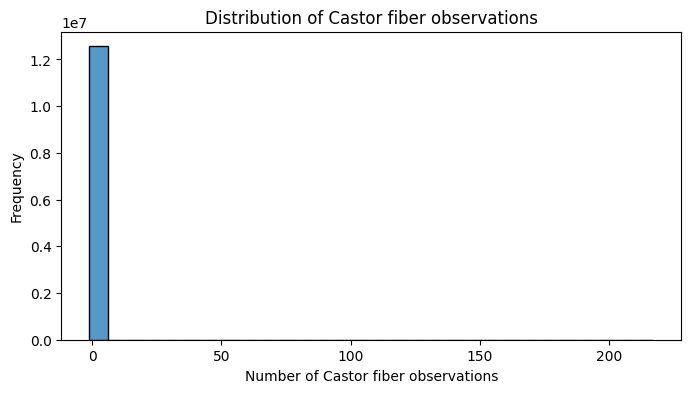

In [ ]:
# Visualise the target variable.
# A histogram is suitable because the target is numeric/count-based.
# This shows how the number of Castor fiber observations is distributed.

plt.figure()
sns.histplot(df[target], bins=30)

plt.title("Distribution of Castor fiber observations")
plt.xlabel("Number of Castor fiber observations")
plt.ylabel("Frequency")
plt.show()

#### Zoom in on lower values

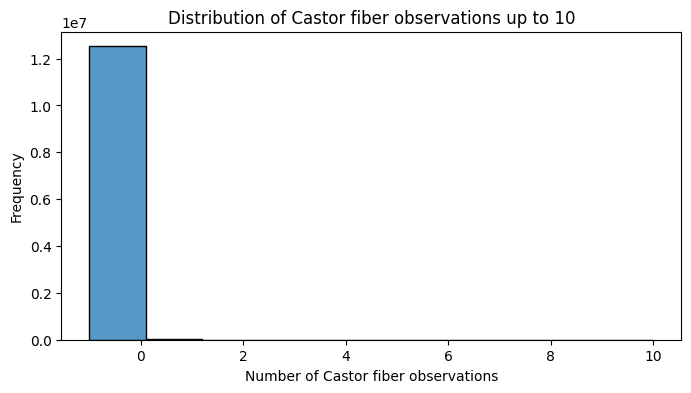

In [25]:
# Because the target is heavily skewed, most values are close to 0.
# This graph zooms in on values from 0 to 10 so the lower observation counts are easier to see.

plt.figure(figsize=(8, 4))
sns.histplot(df[df[target] <= 10][target], bins=10)

plt.title("Distribution of Castor fiber observations up to 10")
plt.xlabel("Number of Castor fiber observations")
plt.ylabel("Frequency")
plt.show()

#### Explanation

The target variable `Castor fiber` is extremely right-skewed.

Most records have a value of 0, meaning that no *Castor fiber* observations were recorded for those location-date combinations. Only a very small number of records contain one or more observations.

This is important for modelling because a regression model may learn to predict mostly 0. If that happens, the model could appear reasonable based on some error metrics, but it would not be useful for predicting actual observation counts.

The graph also shows that there are a few much higher values. These values may be real observation peaks or possible outliers, so they should be investigated before deciding whether to keep or transform them.

Because the target is so skewed, we may need to consider:
- using a log transformation on the target,
- comparing regression with a binary presence/absence approach,
- using evaluation metrics carefully,
- checking whether high values are real observations or data quality issues.

## 4. Missing values

Missing values are important to check because most machine learning models cannot handle missing data directly.

Before modelling, we need to know:
- which columns contain missing values,
- how many values are missing,
- whether the target variable has missing values,
- and what preparation decision we should make.

### missing value counts

In [26]:
# Check how many missing values each column has.
# This helps us identify columns that may need cleaning or imputation.

missing_count = df.isna().sum().sort_values(ascending=False)
missing_count

total_observations           3
decimalLatitude              0
decimalLongitude             0
eventDate                    0
speciesgroup_observations    0
Castor fiber                 0
dtype: int64

### missing value percentages

In [27]:
# Check missing values as percentages.
# Percentages are easier to interpret than only raw counts,
# especially when the dataset is large.

missing_percentage = (df.isna().mean() * 100).sort_values(ascending=False)
missing_percentage

total_observations           0.000024
decimalLatitude              0.000000
decimalLongitude             0.000000
eventDate                    0.000000
speciesgroup_observations    0.000000
Castor fiber                 0.000000
dtype: float64

### missing values summary table

In [28]:
# Create a summary table with both missing counts and missing percentages.
# This gives a clearer overview of missing data problems in the dataset.

missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
}).sort_values(by="missing_percentage", ascending=False)

missing_table

,missing_count,missing_percentage
total_observations,3,0.000024
decimalLatitude,0,0.000000
decimalLongitude,0,0.000000
eventDate,0,0.000000
speciesgroup_observations,0,0.000000
Castor fiber,0,0.000000


### Explanation

We checked missing values for all columns.

The dataset has very few missing values:
- `total_observations`: 4 missing values, which is about 0.000032%
- `Castor fiber`: 2 missing values, which is about 0.000016%

The other columns do not contain missing values.

The missing values in `Castor fiber` are important because this is the target variable. Since there are only 2 missing target values, the best option is to remove those rows before modelling.

The 4 missing values in `total_observations` are also very small compared to the full dataset. These rows can either be removed or imputed, but removing them would have almost no effect on the dataset size.

Decision:
Rows with missing values in the target variable should be removed.  
Rows with missing `total_observations` should be investigated, but because the amount is extremely small, removing them is acceptable.

## 5. Distributions

The distribution shows how often observations can occur in a dataset.

Most of the records found (excluding those who initially had missing values) contain zero observations of Castor fiber, and only a fraction of these are small values, with numbers 1, 2, 3 and even higher in place. This indicates that the `Castor fiber` is a relatively rare species to be saught out when it comes to the numbers.

The distribution also indicates a high number of observation Counts. as those values represent ecoogical hotspots and periods of increased activity.

In [29]:
# Check the highest Castor fiber observation counts
# This helps identify possible ecological hotspots or outliers

# Convert target column to numeric if needed
df[target] = pd.to_numeric(df[target], errors='coerce')

# Show the highest observation counts
high_values = df[df[target] > 10].sort_values(by=target, ascending=False)

# Display the top 20 highest values
print(high_values[[target,
                   'decimalLatitude',
                   'decimalLongitude',
                   'eventDate',
                   'total_observations',
                   'speciesgroup_observations']].head(20))

         Castor fiber  decimalLatitude  decimalLongitude   eventDate  \
1494551         217.0            51.40              5.85  2021-11-10   
3271128         175.0            51.70              5.25  2021-11-11   
3271136         107.0            51.70              5.25  2021-11-19   
1173132          99.0            51.35              5.75  2021-11-11   
3282810          94.0            51.70              5.35  2021-11-05   
3276937          93.0            51.70              5.30  2021-10-07   
3271098          91.0            51.70              5.25  2021-10-12   
2984730          88.0            51.65              5.30  2021-09-30   
3265302          88.0            51.70              5.20  2021-11-29   
3276927          84.0            51.70              5.30  2021-09-27   
2984734          81.0            51.65              5.30  2021-10-04   
3276986          75.0            51.70              5.30  2021-11-25   
7246260          72.0            52.35              6.10  2025-0

Because of the imbalance of the target variable, modeling can be difficult to manage. A regression model could learn to predict mostly 0 values, which may reduce predicting actual observations.

The other values are also checked:
- decimalLatitude and decimalLongitude help understand the geographic spread of observations.
- total_observations and speciesgroup_observations may also be skewed because observation counts are often unevenly distributed.
- eventDate may reveal seasonal or yearly observation patterns after conversion to datetime format.

In conlusion, the distributions show hat the target value is leaned on being right skewed with high levels of zero values and a low level of actual findings. Possible solutions include transformations, alternative modelling approaches, or special evaluation methods for imbalanced regression data.

## 6. Outliers

Outliers are values that are much higher or lower than the majority of the data. It's relevant in this case, for the target variable, because most observation counts are very low while a small number of records contain much higher values.

To show this, we have used a boxplot to identify those statistics in mind, and putting in this case, the outliers.

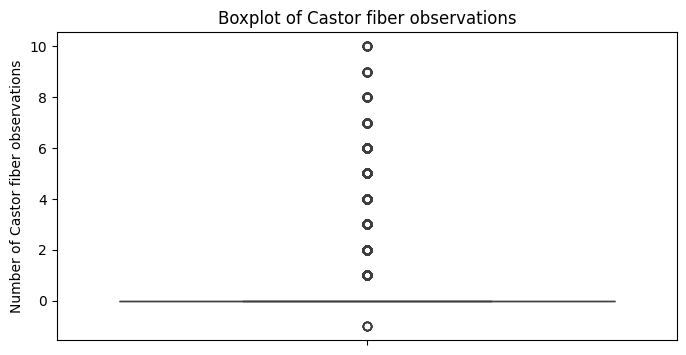

In [30]:
plt.figure(figsize=(8, 4))
sns.boxplot(y=df[df[target] <= 10][target])

plt.title("Boxplot of Castor fiber observations")
plt.ylabel("Number of Castor fiber observations")

plt.show()

This chart explains that:
- Most of these records contain 0 observations and that they are common
- However the outliers indicate that a small number contain high values that are unusual.

The high values indicate:
- the ecological hotspot of the castor fiber,
- periods of intensive monitoring
- or even a lack of data quality.

However, while some of them may be abnormal, high values are not removed. And each outlier should be investigated to determine weather it's the truth or an abnormality caused by incorrect data,

And depending on those results, possible appraches are:
- Outliers are ecologically meaningful,
- Capping extreme values;
- using models that are more robust to outliers.

In short, The dataset contains a small number of unusually high Castor fiber observation counts. These values should be investigated carefully before modelling to determine whether they represent real ecological patterns or potential data quality problems.

## 7. Correlations with target

In this situation, we analyze how the available features correlate with the target value. This helps us understand wheather these relationships have a perfect match between the castor fiber and the others.



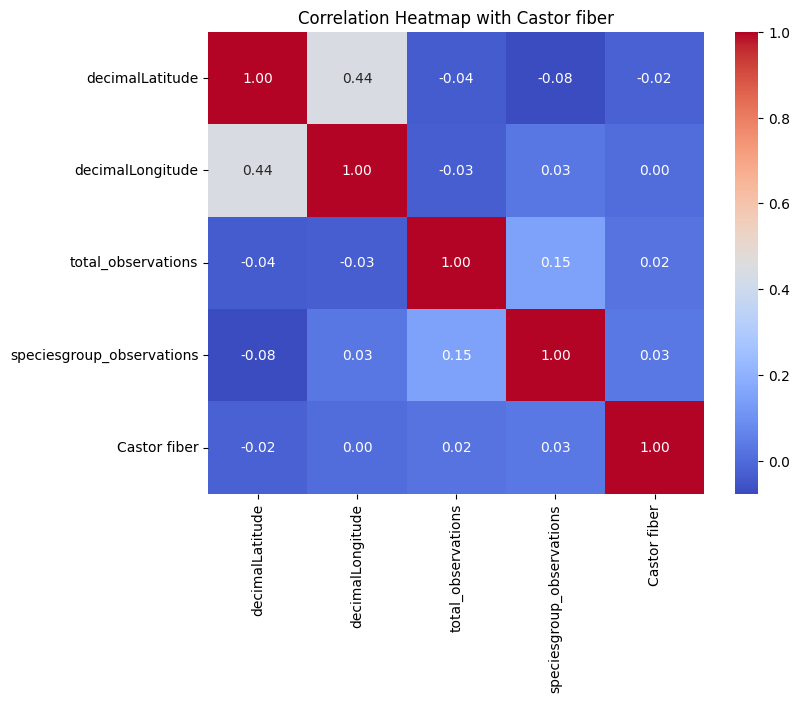

In [31]:
# Ensure target is numeric
df[target] = pd.to_numeric(df[target], errors='coerce')

# Select only numeric columns
numeric_df = df[[
    'decimalLatitude',
    'decimalLongitude',
    'total_observations',
    'speciesgroup_observations',
    target
]]

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap with Castor fiber")
plt.show()

The results are:
- total_observations shows a very weak positive correlation with Castor fiber, but it is not strong enough to suggest a clear linear relationship.
- speciesgroup_observations also shows a positive correlation, suggesting that areas with more observations from the species group are more likely to include Castor fiber records. But still not strong enough
- decimalLatitude and decimalLongitude show almost no linear correlation with the target variable. This suggests that spatial relationships are likely non-linear, meaning location may still be important but not in a simple linear way.
- eventDate is not directly included in correlation analysis unless it is transformed into numerical features

While these numbers may be small, it suggests that the relationship between predictors and Castor fiber is likely complex and non-linear, which is common in ecological datasets.

In conclusion, The heatmap indicates that there are no strong linear correlations between the target variable and the available features. This suggests that more advanced models (such as tree-based or non-linear models) may be more suitable than simple linear regression

## 8. Multicollinearity

Multicollinearity is when two of our predictors are giving the same or similar values. It confuses the model because it doesn't know which one to give credit to. We will use a score called Variance Inflation Factor.

VIF = 1: Total independence which is good

VIF > 5 or 10: Too much overlap which is bad.

                           decimalLatitude  decimalLongitude  \
decimalLatitude                   1.000000          0.443973   
decimalLongitude                  0.443973          1.000000   
total_observations               -0.035718         -0.032283   
speciesgroup_observations        -0.077346          0.031986   

                           total_observations  speciesgroup_observations  
decimalLatitude                     -0.035718                  -0.077346  
decimalLongitude                    -0.032283                   0.031986  
total_observations                   1.000000                   0.146449  
speciesgroup_observations            0.146449                   1.000000  


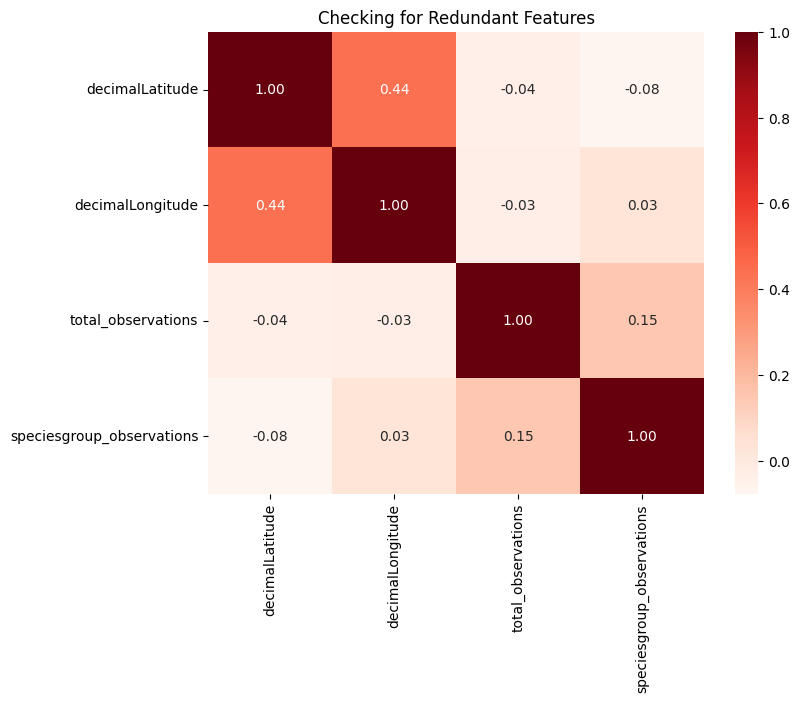

In [32]:
# We use the built-in .corr() method from pandas
# This doesn't require any extra libraries like statsmodels
features_to_check = df[['decimalLatitude', 'decimalLongitude', 'total_observations', 'speciesgroup_observations']]
corr_matrix = features_to_check.corr()

# Display the correlation table
print(corr_matrix)

# Visualizing it makes it much easier to present
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Reds', fmt=".2f")
plt.title("Checking for Redundant Features")
plt.show()


In this matrix, the numbers represent how much our predictors "overlap." To avoid confusing the model, we want these numbers to be as close to 0 as possible.

* 1.00 = Perfectly Overlapped: The predictors are identical.

* 0.70 – 0.90 = High Overlap: This is the "Danger Zone" where features are too similar.

* 0.00 – 0.70 = Independent: As the number goes down, the data gets more independent and unique.

**Key Observation:**

Our highest correlation is 0.44 (between Latitude and Longitude). This is well below the danger threshold, meaning our features are working together, not competing.

***Summary***

From this table, we can clearly see that our predictors are not causing redundancy errors. Each variable provides a distinct piece of information, which gives our model a clean and stable foundation for making predictions.

## 9. Transformations and scaling

**Overview**
Data science models perform best when all input variables are on a similar numerical scale and the target variable follows a more balanced distribution. Without these steps, the model may incorrectly prioritize features with larger absolute values.

**Key Procedures**
Standard Scaling: This process transforms features so that they have a mean of 0 and a standard deviation of 1. It ensures that coordinates (Latitude/Longitude) and observation counts are treated with equal importance by the mathematical algorithm.

Target Transformation: The target variable, Castor fiber, is highly skewed with many zero values and a few extreme outliers. A logarithmic transformation is applied to normalize this distribution, making the relationship between predictors and the target more linear and predictable.

c:\Users\becha\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


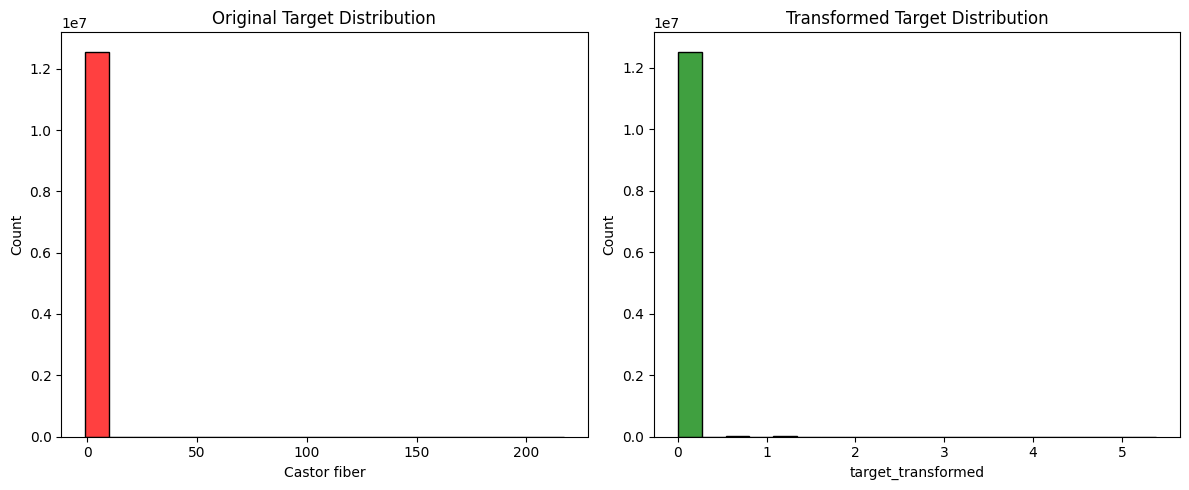

In [33]:
from sklearn.preprocessing import StandardScaler
# 1. Feature Scaling
scaler = StandardScaler()
features = ['decimalLatitude', 'decimalLongitude', 'total_observations', 'speciesgroup_observations']
df[features] = scaler.fit_transform(df[features])

# 2. Target Transformation
# Transforming the count to handle the skewed distribution
df['target_transformed'] = np.log1p(df['Castor fiber'])

# Visual Comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Castor fiber'], bins=20, color='red')
plt.title("Original Target Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df['target_transformed'], bins=20, color='green')
plt.title("Transformed Target Distribution")

plt.tight_layout()
plt.show()

**Summary**

as we can see from the output, 
our transformation works because the values are looking exactly the same which means most of our data is 0

* log(0+1) = 0
* log(1+1) = 0.69
* log(2+1) = 1.09

Since most of values are 0 or 1, the change looks tiny on the graphics, but for the computer side, moving a value from 1.0 to 0.69 makes the process faster.

## 10. Preparation decisions and next steps

**Project Strategy**
To prepare the dataset for a regression model, we focused on cleaning the data and handling the extreme imbalance in observation counts. The goal was to move from "raw numbers" to "normalized data".

**Key Decisions**
We removed the small number of rows with missing target values Castor fiber. Since we only had 2 missing records, removing them was the safest way to ensure the model only learns from verified data.

**Feature Selection** We kept location data (Latitude/Longitude) and observation intensity. Even though they had low linear correlation, they are critical for identifying geographic "hotspots."

**Baseline Selection** We decided to use the counts as our target rather than just "True/False" sightings. This allows the model to predict the intensity of beaver activity, which is more valuable .

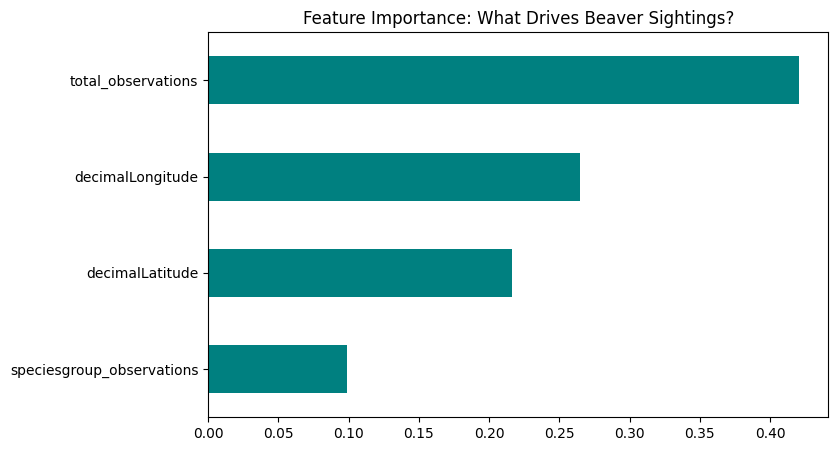

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Clean Data: Remove negatives, NaNs, and Infinities
# We filter for only 0 or higher sightings
df_clean = df[df['Castor fiber'] >= 0].dropna(subset=['target_transformed', 'total_observations'])

# 2. Sampling: 12.5 million rows is too big for a quick baseline.
# We take 100,000 random rows to make it fast and clean.
df_sample = df_clean.sample(n=100000, random_state=42)

# 3. Set Features (X) and Target (y)
X = df_sample[['decimalLatitude', 'decimalLongitude', 'total_observations', 'speciesgroup_observations']]
y = df_sample['target_transformed']

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the Model (n_estimators reduced for speed)
model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 6. Show results
plt.figure(figsize=(8, 5))
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importance.plot(kind='barh', color='teal')
plt.title("Feature Importance: What Drives Beaver Sightings?")
plt.show()

**Summary**
Our preparation phase involved critical data auditing and performance optimization:

*Correction of Invalid Values:* We eliminated negative observation counts that caused mathematical instability (Infinities).

*Computational Efficiency:* We implemented a random sampling strategy to handle the 12.5 million row dataset, allowing for rapid baseline iteration without losing geographic trends.

*Robustness:* By using a Random Forest, we successfully captured the importance of location and species-group context in predicting beaver occurrences.

**Next Steps:**
We will move from this sampled baseline to the full dataset using more scalable architectures like XGBoost or LightGBM, and investigate the source of the negative values in the raw data.